In [390]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Math

x_star = 3

eps = 1e-3
n = 5

x = np.array([0, 1.7, 3.4, 5.1, 6.8])
y = np.array([0, 1.3038, 1.8439, 2.2583, 2.6077])

In [391]:
h = np.concatenate(([0], np.diff(x)))

slau = np.zeros((n - 2, 3), dtype=float)
free = np.zeros(n - 2, dtype=float)

# Интерполяция кубическими сплайнами

Составление СЛАУ для нахождения коэффициентов $c_i$ в кубическом сплайне:

In [392]:
for i in range(1, n - 1):
    slau[i - 1, 0] = h[i]
    slau[i - 1, 1] = 2 * (h[i] + h[i + 1])
    slau[i - 1, 2] = h[i]
    free[i - 1] = 3 * (
        (y[i + 1] - y[i]) / h[i + 1] -
        (y[i] - y[i - 1]) / h[i]
    )
slau[0, 0] = slau[-1, 2] = 0

In [393]:
slau, free

(array([[0. , 6.8, 1.7],
        [1.7, 6.8, 1.7],
        [1.7, 6.8, 0. ]]),
 array([-1.34770588, -0.22182353, -0.11470588]))

Решим системы через метод прогонки для нахождения коэффициентов $c_i$. Используем реализацию из ЛР 1.2

In [394]:
P, Q = np.zeros(n - 1, dtype=float), np.zeros(n - 1, dtype=float)

P[0], Q[0] = 0, 0

for i in range(0, n - 2):
    P[i + 1] = -slau[i, 2] / (slau[i, 1] + slau[i, 0] * P[i])
    Q[i + 1] = (free[i] - slau[i, 0] * Q[i]) / (slau[i, 1] + slau[i, 0] * P[i])

In [395]:
c = np.zeros(n - 2, dtype=float)

for i in range(n - 2, 0, -1):
    if P[i] == 0:
        c[i - 1] = Q[i]
        continue
    c[i - 1] = P[i] * c[i] + Q[i]

c = np.concatenate(([0], c))

Найдём коэффициенты $a_i$, $b_i$, $d_i$ для каждого отрезка сплайна.

In [396]:
a = y[:-1]


b = np.zeros(n - 1, dtype=float)

for i in range(1, n - 1):
    b[i - 1] = (y[i] - y[i - 1]) / h[i] - h[i] * (2 * c[i - 1] + c[i]) / 3

b[-1] = (y[-1] - y[-2]) / h[-1] - 2 * h[-1] * c[-1] / 3


d = np.zeros(n - 1, dtype=float)

for i in range(n - 2):
    d[i] = (c[i + 1] - c[i]) / (3 * h[i + 1])

d[-1] = -c[-1] / (3 * h[-1])

Выражение для сплайна на каждом отрезке $[x_i, x_{i + 1}]$:

In [397]:
import sympy as sp

x_sym = sp.Symbol('x')
S = []
for i in range(n - 1):
    S.append(
        a[i]
        + b[i] * (x_sym - x[i])
        + c[i] * (x_sym - x[i]) ** 2
        + d[i] * (x_sym - x[i]) ** 3
    )
    display(Math(rf"S(x_{{{i}}}) = {sp.latex(sp.expand(S[i]))}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Значение сплайна в точке $x^* = 3$:

In [398]:
from bisect import bisect_left
i = max(0, bisect_left(x, x_star) - 1)

display(Math(rf"f({x_star}) = {float(S[i].subs(x_sym, x_star).evalf())}"))

<IPython.core.display.Math object>

# Валидация

Сравним графики функции и сплайна:

Text(0.5, 1.0, 'Сплайн')

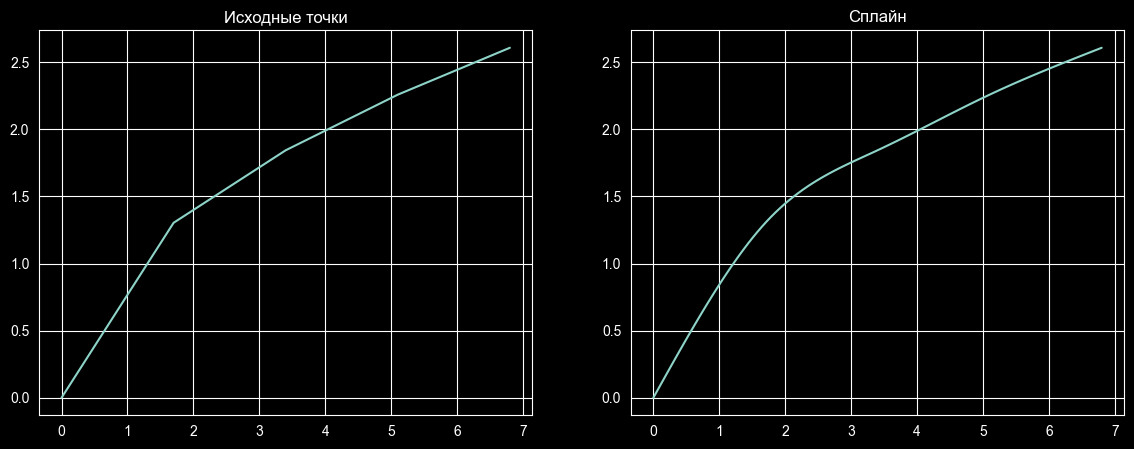

In [399]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x=x, y=y, ax=axes[0])
axes[0].set_title("Исходные точки")

spline_x = np.linspace(x[0], x[-1], 100)
spline_y = np.zeros(len(spline_x))
for i in range(len(spline_x)):
    idx = max(0, bisect_left(x, spline_x[i]) - 1)
    spline_y[i] = float(S[idx].subs(x_sym, spline_x[i]).evalf())

sns.lineplot(x=spline_x, y=spline_y, ax=axes[1])
axes[1].set_title("Сплайн")

In [400]:
spline_first_derivative = [sp.diff(func, x_sym) for func in S]
spline_second_derivative = [sp.diff(func, x_sym, 2) for func in S]

for x_i in x[1:-1]:
    i = max(0, bisect_left(x, x_i) - 1)

    S_i = float(S[i].subs(x_sym, x_i))
    S_i_next = float(S[i + 1].subs(x_sym, x_i))

    spline_first_derivative_i = float(spline_first_derivative[i].subs(x_sym, x_i))
    spline_first_derivative_i_next = float(spline_first_derivative[i + 1].subs(x_sym, x_i))

    spline_second_derivative_i = float(spline_second_derivative[i].subs(x_sym, x_i))
    spline_second_derivative_i_next = float(spline_second_derivative[i + 1].subs(x_sym, x_i))

    print(
        f"Разрыва в точке {x_i} нет: {
        np.allclose(
            S_i,
            S_i_next,
            eps)
        } {
        np.allclose(
          spline_first_derivative_i,
          spline_first_derivative_i_next,
          eps
        )
        } {
        np.allclose(
          spline_second_derivative_i,
          spline_second_derivative_i_next,
          eps
        )
        }"
    )

Разрыва в точке 1.7 нет: True True True
Разрыва в точке 3.4 нет: True True True
Разрыва в точке 5.1 нет: True True True
